# PneumoScan — Détection de pneumonie (RSNA) avec YOLO

Pipeline : DICOM → PNG → format YOLO → entraînement → évaluation (P, R, mAP@50, mAP@50-95).

**Corrections par rapport à la version précédente :**
1. Dataset **équilibré** (tous les positifs + autant de négatifs) au lieu de 200 images aléatoires
2. Modèle de **détection** (`yolo11m`) au lieu de `-seg` : RSNA ne fournit que des boîtes
3. `imgsz=640`, 45 époques, augmentation adaptée aux radiographies
4. Cellules d'évaluation qui produisent les chiffres et les graphiques à présenter

⚠️ Active le GPU : *Settings → Accelerator → GPU T4 x2 (ou P100)*. Durée totale ≈ 2 h 30 – 3 h.

In [1]:
!pip install -q ultralytics pydicom

import torch
print("GPU disponible :", torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠️ Active le GPU dans Settings")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.9 MB/s eta 0:00:00
GPU disponible : True
Tesla T4


## 1. Chargement des annotations

In [2]:
import os, random, shutil
import numpy as np
import pandas as pd

RSNA = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge'
WORK = '/kaggle/working/dataset'

labels = pd.read_csv(f'{RSNA}/stage_2_train_labels.csv')
print("Lignes :", len(labels))
print("Patients uniques :", labels['patientId'].nunique())
print(labels.groupby('patientId')['Target'].max().value_counts())
labels.head()

Lignes : 30227
Patients uniques : 26684
Target
0    20672
1     6012
Name: count, dtype: int64


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


## 2. Sélection d'un dataset équilibré

Le déséquilibre (≈ 6 000 positifs contre 20 000 négatifs) est ce qui écrase la précision : le modèle apprend à ne rien prédire. On garde **tous les positifs** et **1 négatif par positif**.

In [3]:
RATIO_NEGATIFS = 1.0   # 1.0 = équilibré. Mets 0.5 pour aller plus vite, 2.0 pour plus de réalisme clinique
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# boîtes regroupées par patient
boites = {}
for r in labels.itertuples(index=False):
    d = boites.setdefault(r.patientId, [])
    if r.Target == 1 and not pd.isna(r.x):
        d.append([r.x, r.y, r.width, r.height])

positifs = [p for p, b in boites.items() if len(b) > 0]
negatifs = [p for p, b in boites.items() if len(b) == 0]
negatifs = random.sample(negatifs, min(len(negatifs), int(len(positifs) * RATIO_NEGATIFS)))

ids = positifs + negatifs
cible = [1] * len(positifs) + [0] * len(negatifs)
print(f"Positifs : {len(positifs)} | Négatifs retenus : {len(negatifs)} | Total : {len(ids)}")

Positifs : 6012 | Négatifs retenus : 6012 | Total : 12024


In [4]:
from sklearn.model_selection import train_test_split

# split stratifié par patient : aucune fuite de données entre train et val
train_ids, val_ids = train_test_split(ids, test_size=0.2, random_state=SEED, stratify=cible)
print("Train :", len(train_ids), "| Val :", len(val_ids))

Train : 9619 | Val : 2405


## 3. Conversion DICOM → PNG + labels YOLO

Format YOLO détection : `classe cx cy w h` normalisés entre 0 et 1. Un fichier `.txt` vide = image négative (arrière-plan), ce qui est utile et attendu par Ultralytics.

In [5]:
import pydicom
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

TAILLE_PNG = 640   # on redimensionne dès la conversion : disque + entraînement plus rapides

for split in ['train', 'val']:
    os.makedirs(f'{WORK}/images/{split}', exist_ok=True)
    os.makedirs(f'{WORK}/labels/{split}', exist_ok=True)

def convertir(pid, split):
    ds = pydicom.dcmread(f'{RSNA}/stage_2_train_images/{pid}.dcm')
    img = ds.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-6) * 255.0
    h, w = img.shape
    im = Image.fromarray(img.astype(np.uint8))
    if TAILLE_PNG:
        im = im.resize((TAILLE_PNG, TAILLE_PNG), Image.BILINEAR)
    im.save(f'{WORK}/images/{split}/{pid}.png')

    lignes = []
    for x, y, bw, bh in boites[pid]:
        cx, cy = (x + bw / 2) / w, (y + bh / 2) / h
        nw, nh = bw / w, bh / h
        lignes.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
    with open(f'{WORK}/labels/{split}/{pid}.txt', 'w') as f:
        f.write('\n'.join(lignes))

for split, liste in [('train', train_ids), ('val', val_ids)]:
    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(lambda p: convertir(p, split), liste), total=len(liste), desc=split))

print("Images train :", len(os.listdir(f'{WORK}/images/train')))
print("Images val   :", len(os.listdir(f'{WORK}/images/val')))

train:   0%|          | 0/9619 [00:00<?, ?it/s]

val:   0%|          | 0/2405 [00:00<?, ?it/s]

Images train : 9619
Images val   : 2405


In [6]:
data_yaml = f"""path: {WORK}
train: images/train
val: images/val
nc: 1
names:
  0: pneumonie
"""
with open(f'{WORK}/data.yaml', 'w') as f:
    f.write(data_yaml)
print(data_yaml)

path: /kaggle/working/dataset
train: images/train
val: images/val
nc: 1
names:
  0: pneumonie



## 4. Vérification visuelle des annotations (à mettre dans la présentation)

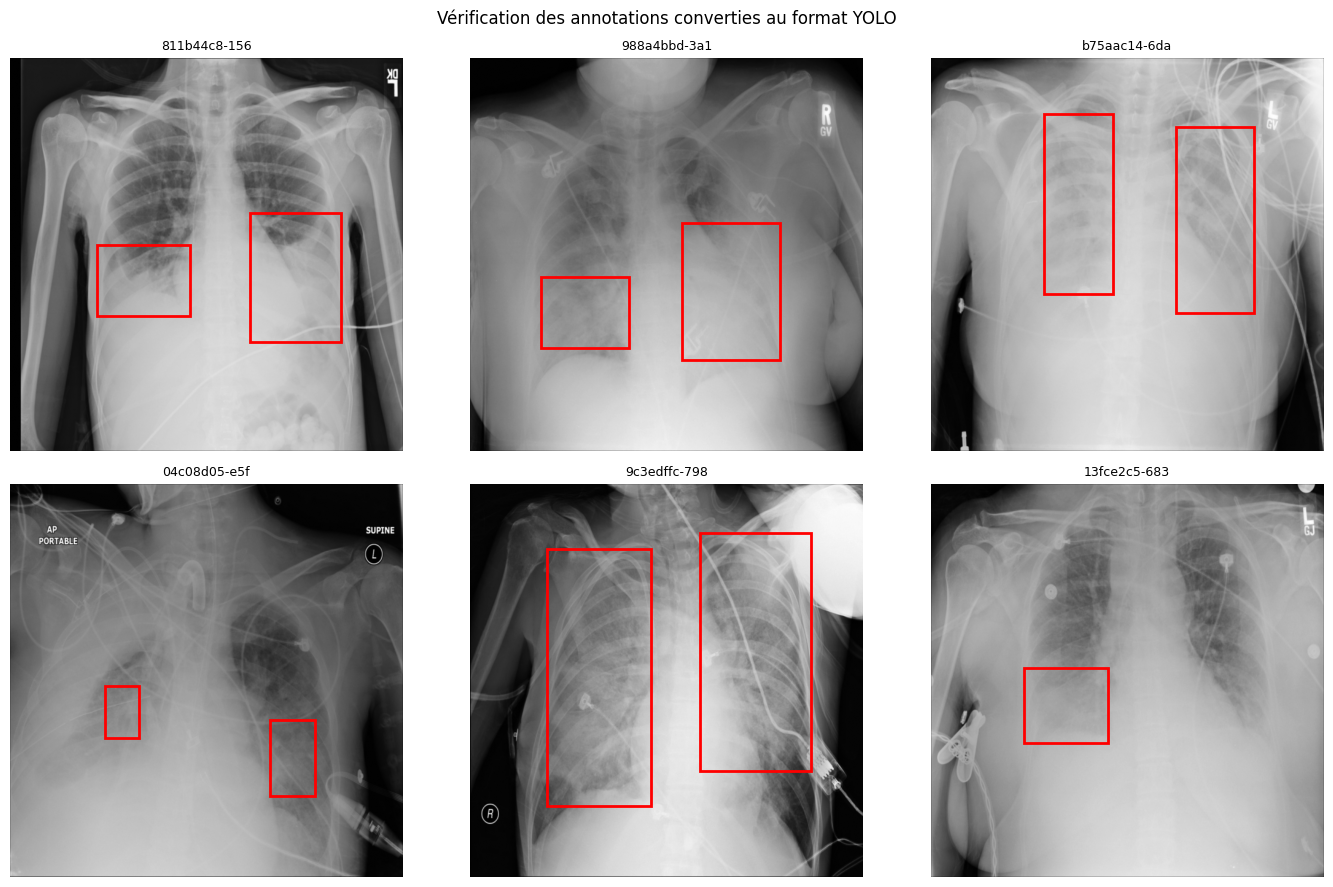

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

exemples = [p for p in train_ids if len(boites[p]) > 0][:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, pid in zip(axes.ravel(), exemples):
    im = Image.open(f'{WORK}/images/train/{pid}.png')
    ax.imshow(im, cmap='gray')
    for ligne in open(f'{WORK}/labels/train/{pid}.txt').read().splitlines():
        _, cx, cy, nw, nh = map(float, ligne.split())
        W, H = im.size
        ax.add_patch(patches.Rectangle(((cx - nw/2)*W, (cy - nh/2)*H), nw*W, nh*H,
                                       fill=False, edgecolor='red', linewidth=2))
    ax.set_title(pid[:12], fontsize=9); ax.axis('off')
plt.suptitle("Vérification des annotations converties au format YOLO")
plt.tight_layout(); plt.show()

## 5. Entraînement

Hyperparamètres choisis pour la radiographie thoracique : pas de teinte/saturation (images en niveaux de gris), pas de retournement vertical (anatomie fixe), rotations faibles.

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11m.pt')

resultats = model.train(
    data=f'{WORK}/data.yaml',
    epochs=45,
    imgsz=640,
    batch=16,
    save_period=5,
    project='/kaggle/working/pneumoscan_runs',
    name='pneumoscan_yolo11m',
    exist_ok=True,
    seed=SEED,

    # optimisation
    optimizer='AdamW',
    lr0=0.001, lrf=0.01, cos_lr=True,
    warmup_epochs=3.0, weight_decay=0.0005,
    patience=15,

    # ponderation des pertes (localisation privilegiee)
    box=7.5, cls=0.5, dfl=1.5,

    # augmentation adaptee aux radios
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.3,
    degrees=7.0, translate=0.1, scale=0.25,
    shear=0.0, perspective=0.0,
    fliplr=0.5, flipud=0.0,
    mosaic=0.6, close_mosaic=10, mixup=0.0, erasing=0.2,

    single_cls=True, amp=True, plots=True, workers=4, cache=False,
)


## 6. Évaluation — les chiffres à présenter

In [ ]:
RUN = '/kaggle/working/pneumoscan_runs/pneumoscan_yolo11m'
best = YOLO(f'{RUN}/weights/best.pt')

m = best.val(data=f'{WORK}/data.yaml', imgsz=640, split='val', plots=True)

tableau = pd.DataFrame([{
    'Précision (P)': round(m.box.mp, 4),
    'Rappel (R)':    round(m.box.mr, 4),
    'mAP@0.5':       round(m.box.map50, 4),
    'mAP@0.5:0.95':  round(m.box.map, 4),
    'F1':            round(2 * m.box.mp * m.box.mr / (m.box.mp + m.box.mr + 1e-9), 4),
}])
display(tableau)
tableau.to_csv('/kaggle/working/metriques_finales.csv', index=False)

In [ ]:
# Balayage du seuil de confiance : sert à justifier le seuil retenu dans la présentation
lignes = []
for conf in [0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]:
    r = best.val(data=f'{WORK}/data.yaml', imgsz=640, conf=conf, plots=False, verbose=False)
    p, rec = r.box.mp, r.box.mr
    lignes.append({'conf': conf, 'Précision': round(p, 4), 'Rappel': round(rec, 4),
                   'F1': round(2*p*rec/(p+rec+1e-9), 4), 'mAP@0.5': round(r.box.map50, 4)})

sweep = pd.DataFrame(lignes)
display(sweep)
meilleur = sweep.loc[sweep['F1'].idxmax()]
print(f"\nMeilleur compromis : conf={meilleur['conf']} → P={meilleur['Précision']}, R={meilleur['Rappel']}, F1={meilleur['F1']}")
sweep.to_csv('/kaggle/working/balayage_seuil.csv', index=False)

In [ ]:
# Graphiques générés par Ultralytics : à insérer directement dans les diapositives
from IPython.display import Image as IPImage, display as dsp
for f in ['results.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png',
          'F1_curve.png', 'confusion_matrix_normalized.png', 'val_batch0_pred.jpg']:
    chemin = f'{RUN}/{f}'
    if os.path.exists(chemin):
        print('—', f); dsp(IPImage(filename=chemin, width=780))

In [ ]:
# Prédictions vs vérité terrain sur quelques cas de validation
cas = [p for p in val_ids if len(boites[p]) > 0][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, pid in zip(axes.ravel(), cas):
    chemin = f'{WORK}/images/val/{pid}.png'
    im = Image.open(chemin); W, H = im.size
    ax.imshow(im, cmap='gray')
    for ligne in open(f'{WORK}/labels/val/{pid}.txt').read().splitlines():   # vérité (vert)
        _, cx, cy, nw, nh = map(float, ligne.split())
        ax.add_patch(patches.Rectangle(((cx-nw/2)*W, (cy-nh/2)*H), nw*W, nh*H,
                                       fill=False, edgecolor='lime', linewidth=2))
    pred = best.predict(chemin, conf=float(meilleur['conf']), verbose=False)[0]
    for b in pred.boxes:                                                     # prédiction (rouge)
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                       edgecolor='red', linewidth=2, linestyle='--'))
        ax.text(x1, y1-5, f"{float(b.conf):.2f}", color='red', fontsize=9)
    ax.axis('off')
plt.suptitle("Vert = vérité terrain | Rouge pointillé = prédiction du modèle")
plt.tight_layout(); plt.savefig('/kaggle/working/comparaison_predictions.png', dpi=130); plt.show()

In [ ]:
from IPython.display import FileLink
display(FileLink(f'{RUN}/weights/best.pt'))
display(FileLink('/kaggle/working/metriques_finales.csv'))
display(FileLink('/kaggle/working/balayage_seuil.csv'))